<a href="https://colab.research.google.com/github/endahwulandari2005-code/aplikasidicoding/blob/main/Data_Clustering_Wulandari.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
from google.colab import files
uploaded = files.upload()

Saving Mall_Customers.csv to Mall_Customers (1).csv


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [ ]:
from sklearn.cluster import KMeans

In [ ]:
df = pd.read_csv('Mall_Customers.csv')
df.head()

,CustomerID,Genre,Age,Annual Income (k$),Spending Score (1-100)
0,1,Male,19,15,39
1,2,Male,21,15,81
2,3,Female,20,16,6
3,4,Female,23,16,77
4,5,Female,31,17,40


## Memeriksa Nilai Negatif dalam Data

In [ ]:
negative_values_found = False
numerical_cols = df.select_dtypes(include=np.number).columns

for col in numerical_cols:
    if (df[col] < 0).any():
        print(f"Column '{col}' contains negative values.")
        negative_values_found = True

if not negative_values_found:
    print("Tidak ada nilai negatif yang ditemukan di kolom numerik data Anda.")

Tidak ada nilai negatif yang ditemukan di kolom numerik data Anda.


##Pilih variabel penting/fitur (feature selection)

Biasanya dipakai:
1. Annual Income
2. Spending Score

ini sangat memengaruhi hasil cluster

In [ ]:
X = df[['Annual Income (k$)', 'Spending Score (1-100)']]

##Preprocessing Data

biasanya meliputi:
1. normalisasi/standarisasi
2. encoding (kalau ada data kategori)

mengapa penting?

Karena clustering berbasis jarak, jadi skalanya harus seimbang

In [ ]:
#Normalisasi data
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

##Menentukan jumlah cluster (Elbow Method)

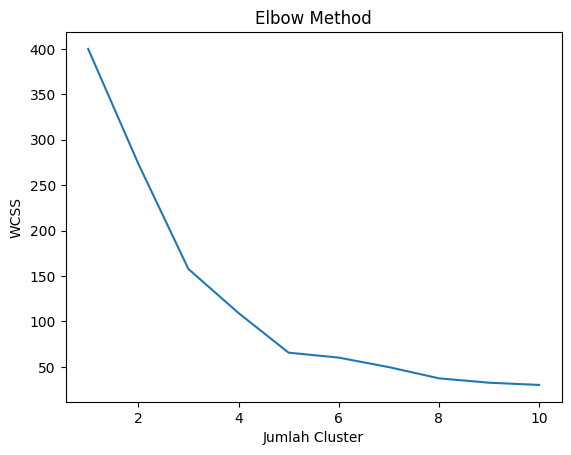

In [ ]:
wcss = []

for i in range(1, 11):
    kmeans = KMeans(n_clusters=i, random_state=42)
    kmeans.fit(X_scaled)
    wcss.append(kmeans.inertia_)

plt.plot(range(1, 11), wcss)
plt.title('Elbow Method')
plt.xlabel('Jumlah Cluster')
plt.ylabel('WCSS')
plt.show()

## Menentukan Jumlah Cluster (Silhouette Analysis)



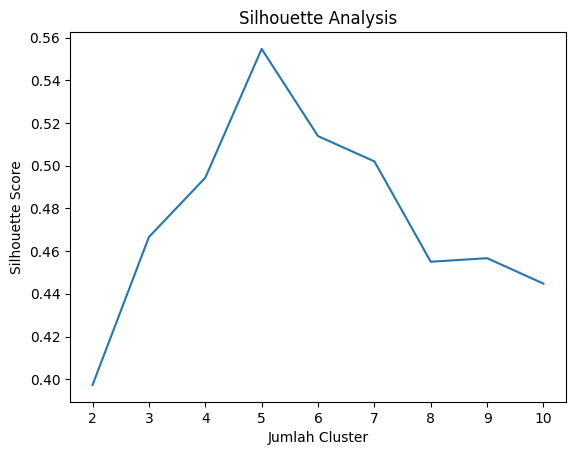

Jumlah cluster optimal berdasarkan Silhouette Analysis: 5


In [ ]:
from sklearn.metrics import silhouette_score

silhouette_scores = []

# Silhouette Score tidak terdefinisi untuk 1 cluster, jadi kita mulai dari 2
for i in range(2, 11):
    kmeans = KMeans(n_clusters=i, random_state=42)
    kmeans.fit(X_scaled)
    score = silhouette_score(X_scaled, kmeans.labels_)
    silhouette_scores.append(score)

plt.plot(range(2, 11), silhouette_scores)
plt.title('Silhouette Analysis')
plt.xlabel('Jumlah Cluster')
plt.ylabel('Silhouette Score')
plt.show()

# Menemukan jumlah cluster dengan Silhouette Score tertinggi
optimal_clusters_silhouette = range(2, 11)[np.argmax(silhouette_scores)]
print(f"Jumlah cluster optimal berdasarkan Silhouette Analysis: {optimal_clusters_silhouette}")

## Menentukan Jumlah Cluster (Calinski-Harabasz Index / Pseudo-F)



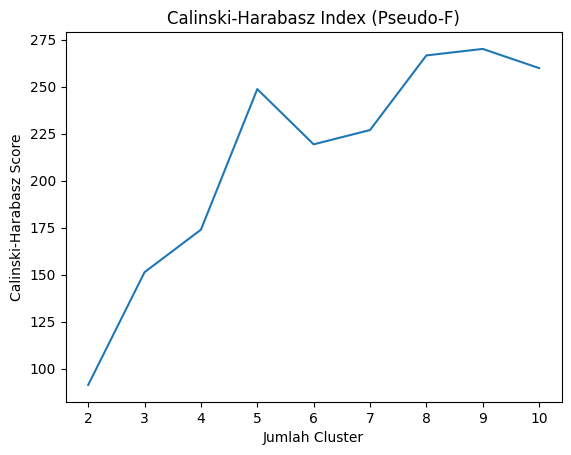

Jumlah cluster optimal berdasarkan Calinski-Harabasz Index: 9


In [ ]:
from sklearn.metrics import calinski_harabasz_score

calinski_harabasz_scores = []

# Calinski-Harabasz Index tidak terdefinisi untuk 1 cluster, jadi kita mulai dari 2
for i in range(2, 11):
    kmeans = KMeans(n_clusters=i, random_state=42)
    kmeans.fit(X_scaled)
    score = calinski_harabasz_score(X_scaled, kmeans.labels_)
    calinski_harabasz_scores.append(score)

plt.plot(range(2, 11), calinski_harabasz_scores)
plt.title('Calinski-Harabasz Index (Pseudo-F)')
plt.xlabel('Jumlah Cluster')
plt.ylabel('Calinski-Harabasz Score')
plt.show()

# Menemukan jumlah cluster dengan Calinski-Harabasz Score tertinggi
optimal_clusters_ch = range(2, 11)[np.argmax(calinski_harabasz_scores)]
print(f"Jumlah cluster optimal berdasarkan Calinski-Harabasz Index: {optimal_clusters_ch}")

##Algoritma Clustering
ada beberapa pilihan:
1. K-Means
2. Hierarchical
3. DBSCAN



##K-Means

In [ ]:
kmeans = KMeans(n_clusters=9, random_state=42)
y_kmeans = kmeans.fit_predict(X_scaled)

In [ ]:
kmeans = KMeans(n_clusters=5, random_state=42)
y_kmeans = kmeans.fit_predict(X_scaled)

##Visualisasi Hasil

## Visualisasi Hasil Clustering (5 Cluster)

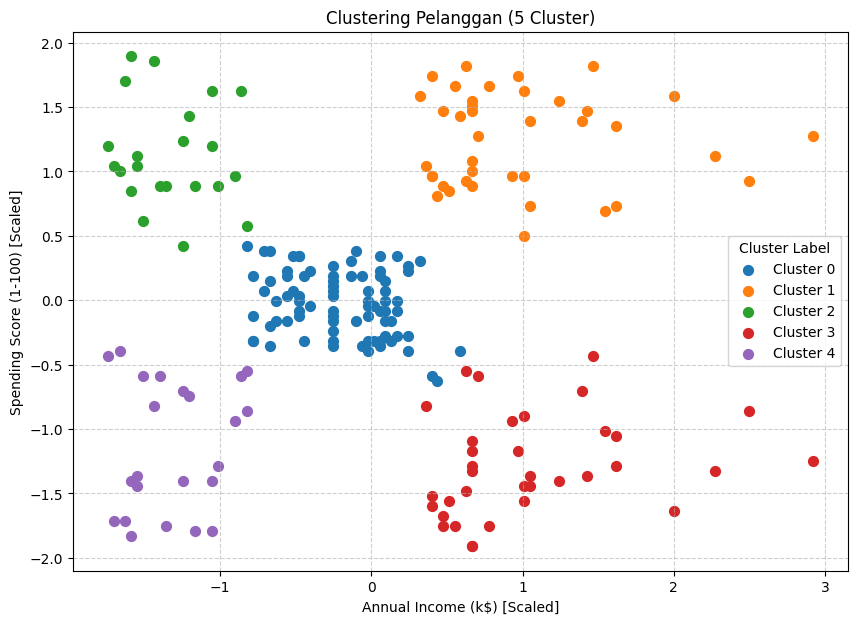

In [ ]:
# Pastikan K-Means dengan 5 cluster sudah dijalankan dan y_kmeans tersedia
# Jika belum, uncomment baris berikut:
# kmeans = KMeans(n_clusters=5, random_state=42)
# y_kmeans = kmeans.fit_predict(X_scaled)

plt.figure(figsize=(10, 7))
# Untuk menambahkan legenda, kita perlu memplot setiap cluster secara terpisah
for i in range(5):
    plt.scatter(X_scaled[y_kmeans == i, 0], X_scaled[y_kmeans == i, 1], label=f'Cluster {i}', s=50)

plt.title('Clustering Pelanggan (5 Cluster)')
plt.xlabel('Annual Income (k$) [Scaled]')
plt.ylabel('Spending Score (1-100) [Scaled]')
plt.legend(title='Cluster Label')
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

## Visualisasi Hasil Clustering (9 Cluster)

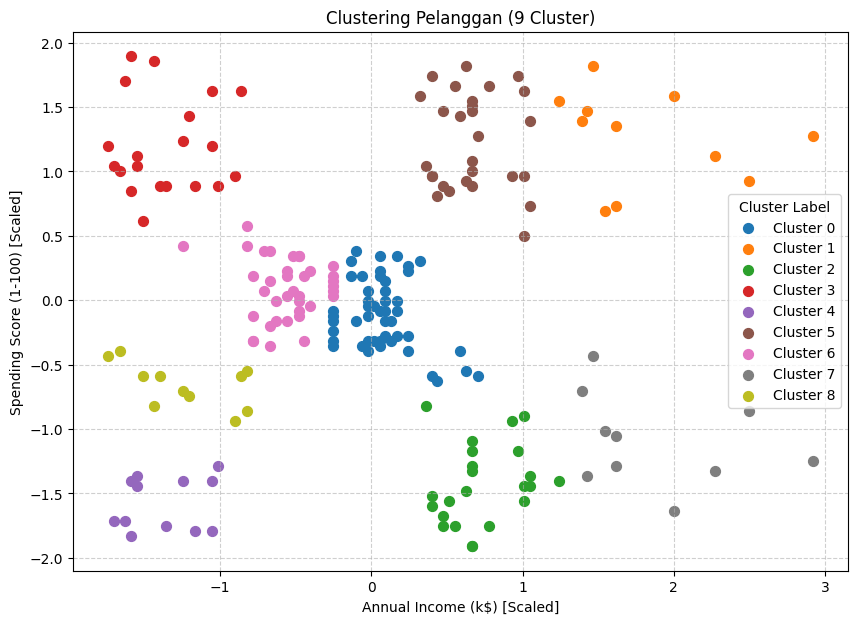

In [ ]:
# Pastikan K-Means dengan 9 cluster sudah dijalankan dan y_kmeans_9 tersedia
# Jika belum, uncomment baris berikut:
# kmeans_9 = KMeans(n_clusters=9, random_state=42)
# y_kmeans_9 = kmeans_9.fit_predict(X_scaled)

plt.figure(figsize=(10, 7))
# Untuk menambahkan legenda, kita perlu memplot setiap cluster secara terpisah
for i in range(9):
    plt.scatter(X_scaled[y_kmeans_9 == i, 0], X_scaled[y_kmeans_9 == i, 1], label=f'Cluster {i}', s=50)

plt.title('Clustering Pelanggan (9 Cluster)')
plt.xlabel('Annual Income (k$) [Scaled]')
plt.ylabel('Spending Score (1-100) [Scaled]')
plt.legend(title='Cluster Label')
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

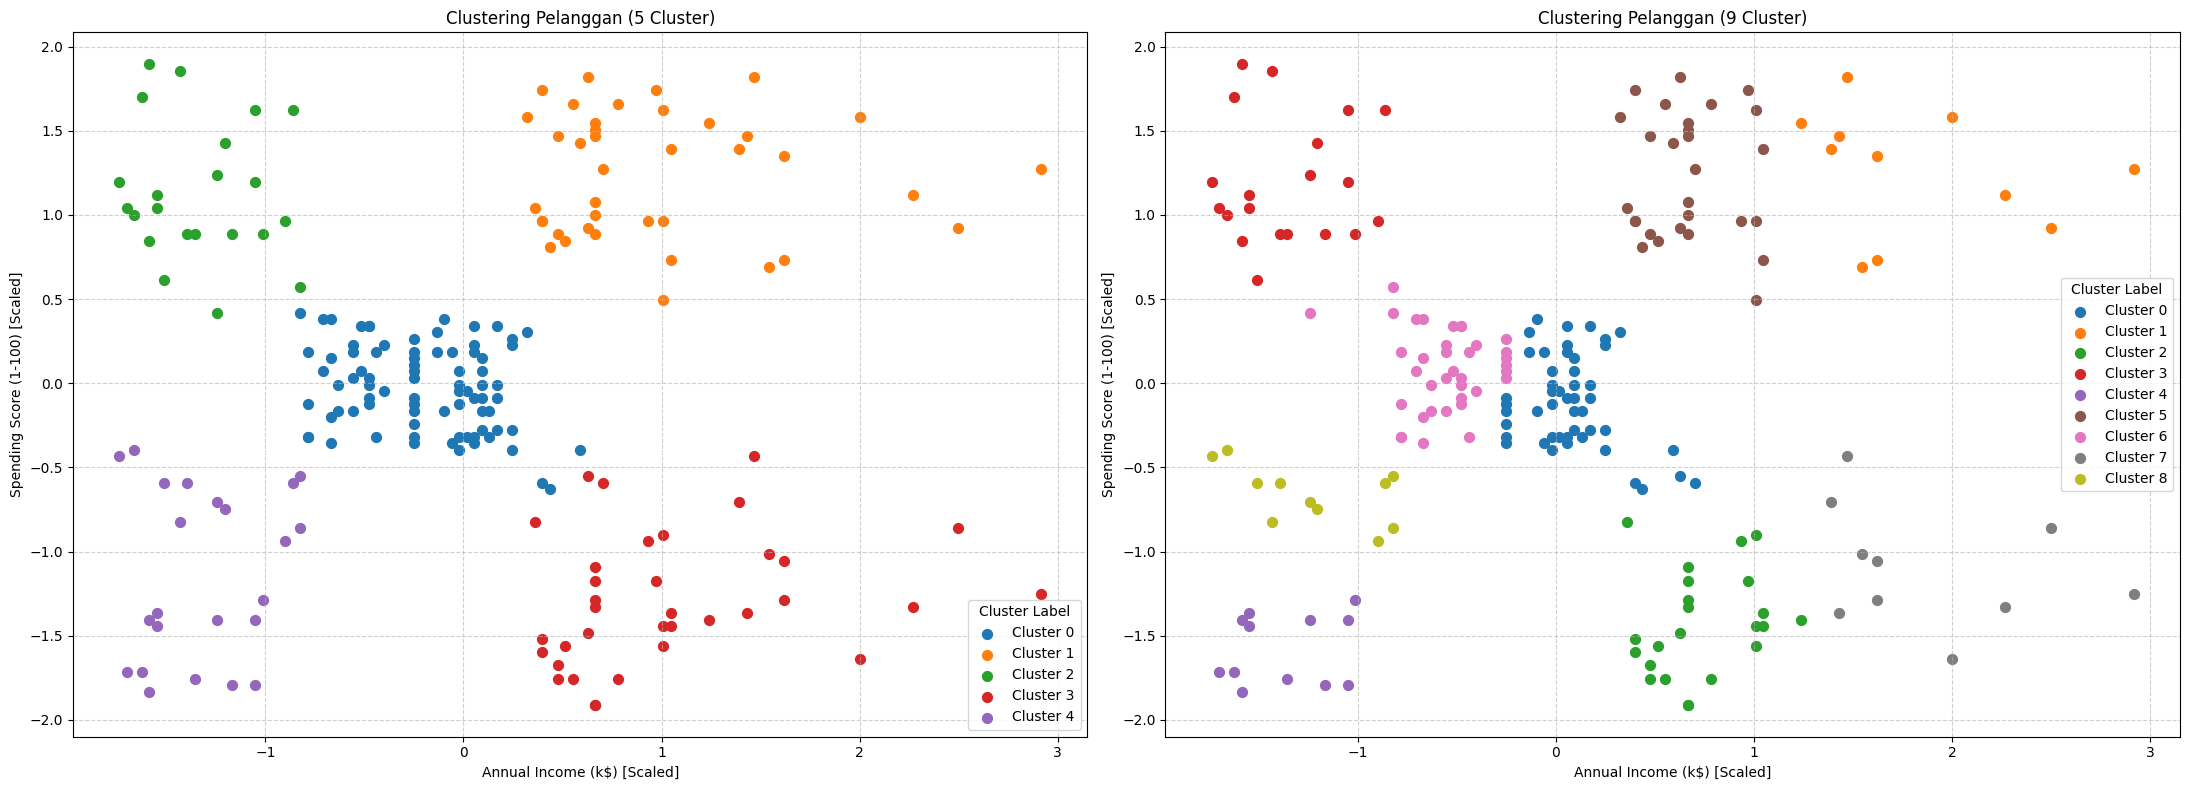

In [ ]:
# Jalankan K-Means dengan 9 cluster untuk visualisasi perbandingan (jika belum dijalankan)
# Note: y_kmeans sudah ada dari 5 cluster sebelumnya
kmeans_9 = KMeans(n_clusters=9, random_state=42)
y_kmeans_9 = kmeans_9.fit_predict(X_scaled)

# Buat figure dan axes untuk dua subplot
fig, axes = plt.subplots(1, 2, figsize=(22, 8)) # 1 baris, 2 kolom, sedikit lebih lebar untuk legenda

# --- Plot untuk 5 Cluster ---
# Untuk menambahkan legenda, kita perlu memplot setiap cluster secara terpisah
for i in range(5):
    axes[0].scatter(X_scaled[y_kmeans == i, 0], X_scaled[y_kmeans == i, 1], label=f'Cluster {i}', s=50)
axes[0].set_title('Clustering Pelanggan (5 Cluster)')
axes[0].set_xlabel('Annual Income (k$) [Scaled]')
axes[0].set_ylabel('Spending Score (1-100) [Scaled]')
axes[0].legend(title='Cluster Label') # Tambahkan legenda
axes[0].grid(True, linestyle='--', alpha=0.6)

# --- Plot untuk 9 Cluster ---
# Untuk menambahkan legenda, kita perlu memplot setiap cluster secara terpisah
for i in range(9):
    axes[1].scatter(X_scaled[y_kmeans_9 == i, 0], X_scaled[y_kmeans_9 == i, 1], label=f'Cluster {i}', s=50)
axes[1].set_title('Clustering Pelanggan (9 Cluster)')
axes[1].set_xlabel('Annual Income (k$) [Scaled]')
axes[1].set_ylabel('Spending Score (1-100) [Scaled]')
axes[1].legend(title='Cluster Label') # Tambahkan legenda
axes[1].grid(True, linestyle='--', alpha=0.6)

plt.tight_layout() # Sesuaikan layout agar tidak tumpang tindih
plt.show()

##validasi hasil clustering

 menggunakan metrik Silhouette Score

In [ ]:
silhouette_score_5_clusters = silhouette_score(X_scaled, y_kmeans)
print(f"Silhouette Score untuk 5 cluster: {silhouette_score_5_clusters}")
print(f"Silhouette Score untuk 9 cluster: {silhouette_score_9_clusters}")

if silhouette_score_5_clusters > silhouette_score_9_clusters:
    print("\nHasil clustering dengan 5 cluster memiliki Silhouette Score yang lebih tinggi, menunjukkan pemisahan cluster yang lebih baik.")
elif silhouette_score_9_clusters > silhouette_score_5_clusters:
    print("\nHasil clustering dengan 9 cluster memiliki Silhouette Score yang lebih tinggi, menunjukkan pemisahan cluster yang lebih baik.")
else:
    print("\nKedua hasil clustering memiliki Silhouette Score yang sama.")

Silhouette Score untuk 5 cluster: 0.5546571631111091
Silhouette Score untuk 9 cluster: 0.4566624374485964

Hasil clustering dengan 5 cluster memiliki Silhouette Score yang lebih tinggi, menunjukkan pemisahan cluster yang lebih baik.


Karena Silhouette Score untuk 5 cluster (sekitar 0.55) lebih tinggi dibandingkan dengan 9 cluster (sekitar 0.45), ini menunjukkan bahwa clustering dengan 5 cluster memiliki pemisahan cluster yang lebih baik dan cluster-clusternya lebih padat dan terdefinisi dengan baik dibandingkan dengan clustering 9 cluster untuk dataset ini. Dengan kata lain, model dengan 5 cluster menghasilkan pengelompokan yang lebih 'jelas' dan 'bermakna' menurut metrik Silhouette.

In [ ]:
#Mencari rata-rata dari setiap kelompok cluster
df['Cluster'] = y_kmeans
df.groupby('Cluster').mean(numeric_only=True)

,CustomerID,Age,Annual Income (k$),Spending Score (1-100)
Cluster,,,,
0,86.320988,42.716049,55.296296,49.518519
1,162.000000,32.692308,86.538462,82.128205
2,23.090909,25.272727,25.727273,79.363636
3,164.371429,41.114286,88.200000,17.114286
4,23.000000,45.217391,26.304348,20.913043


interpretasi
1. Cluster 0:

- Karakteristik: Usia sekitar 43 tahun, pendapatan tahunan sekitar $55.000, dan skor pengeluaran sekitar 50.
- "Cluster ini terdiri dari pelanggan dengan usia paruh baya, pendapatan dan skor pengeluaran yang moderat." (Mereka adalah 'pelanggan rata-rata' atau 'tipe umum').

2. Cluster 1:

- Karakteristik: Usia sekitar 33 tahun, pendapatan tahunan tinggi sekitar $86.000, dan skor pengeluaran sangat tinggi sekitar 82.
- "Cluster ini mewakili 'pelanggan berpenghasilan tinggi dan suka berbelanja' (High-Income, High-Spending). Mereka cenderung lebih muda dan memiliki daya beli yang besar." (Ini adalah target ideal untuk promosi barang mewah).

3. Cluster 2:

- Karakteristik: Usia sangat muda sekitar 25 tahun, pendapatan tahunan rendah sekitar $25.000, tetapi skor pengeluaran sangat tinggi sekitar 79.
- "Cluster ini adalah 'pelanggan muda dengan pendapatan rendah namun sangat suka berbelanja' (Young, Low-Income, High-Spending). Mereka mungkin menghabiskan sebagian besar pendapatan mereka untuk berbelanja, atau mungkin sedang dalam tahap awal karir." (Bisa jadi mereka mencari penawaran atau produk yang trendi).

4. Cluster 3:

- Karakteristik: Usia sekitar 41 tahun, pendapatan tahunan tinggi sekitar $88.000, tetapi skor pengeluaran sangat rendah sekitar 17.
- "Cluster ini adalah 'pelanggan berpenghasilan tinggi namun hemat' (High-Income, Low-Spending). Mereka mungkin menabung lebih banyak atau hanya berbelanja untuk kebutuhan esensial." (Mungkin menarik bagi produk investasi atau layanan premium yang tidak berorientasi pada belanja impulsif).

5. Cluster 4:

- Karakteristik: Usia lebih tua sekitar 45 tahun, pendapatan tahunan rendah sekitar $26.000, dan skor pengeluaran sangat rendah sekitar 21.
- "Cluster ini terdiri dari 'pelanggan dengan pendapatan rendah dan sangat hemat' (Low-Income, Low-Spending). Mereka mungkin sangat berhati-hati dalam pengeluaran mereka." (Mungkin menargetkan penawaran diskon, produk esensial, atau program loyalitas).


##Mengembangkan strategi pemasaran yang ditargetkan

- Cluster 1 ('High-Income, High-Spending'): Kelompok ini adalah target ideal untuk produk-produk premium, layanan eksklusif, dan penawaran personalisasi yang meningkatkan pengalaman belanja mereka. Anda bisa berinvestasi dalam kampanye yang menyoroti kualitas, kemewahan, atau status.
- Cluster 3 ('High-Income, Low-Spending'): Kelompok ini mungkin tertarik pada penawaran nilai, diskon strategis untuk barang-barang tertentu, atau promosi yang berfokus pada investasi jangka panjang. Mungkin mereka juga tertarik pada produk yang tidak berorientasi pada belanja impulsif, seperti investasi atau layanan keuangan.
- Cluster 2 ('Young, Low-Income, High-Spending'): Kelompok ini mungkin merespons baik promosi diskon, penawaran bundle, atau produk yang trendy dan terjangkau. Pemasaran melalui media sosial atau influencer mungkin sangat efektif untuk mereka.
- Cluster 4 ('Low-Income, Low-Spending'): Kelompok ini sangat sensitif terhadap harga. Penawaran diskon besar, program loyalitas, atau produk esensial dengan harga kompetitif akan menarik bagi mereka.
 - Cluster 0 ('Pelanggan Rata-rata'): Kelompok ini bisa menjadi 'benchmark' atau target untuk kampanye umum, atau Anda bisa mencoba mendorong mereka ke segmen 'High-Spending' dengan penawaran menarik.


##Kesimpulan
Analisis clustering ini berhasil mengidentifikasi lima segmen pelanggan yang berbeda di sebuah mal, berdasarkan pendapatan tahunan dan skor pengeluaran mereka. Dengan menggunakan metode K-Means, kita dapat mengelompokkan pelanggan menjadi kategori-kategori seperti 'Pelanggan Berpenghasilan Tinggi & Suka Berbelanja', 'Pelanggan Hemat', dan 'Pelanggan Rata-rata', yang masing-masing memiliki karakteristik demografi dan perilaku belanja yang unik. Pemahaman mendalam tentang segmen-segmen ini memungkinkan pengembangan strategi pemasaran yang lebih tepat sasaran, personalisasi penawaran, dan optimasi komunikasi untuk meningkatkan engagement pelanggan serta profitabilitas bisnis secara keseluruhan.

